# 02a · Classify by nearest neighbours (k-NN)

*The most intuitive classifier there is — no training, just look at your neighbours.*

> ⏱ **Runtime:** ~10 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** Al–Cu map

### 🎯 What you'll learn
1. the idea behind **k-nearest-neighbours**: 'you are like your closest examples',
2. how the choice of **k** changes the **decision boundary**,
3. the **overfitting ↔ underfitting** trade-off, seen with your own eyes,
4. why k-NN needs **standardised** features to measure distance fairly.

### 🧭 What you need to know first
- Notebook **01** (standardisation) and **01a** (what a classifier and decision boundary are).
- Labels again come from clustering the public Al–Cu map (notebook 02).

> 🧠 **How k-NN works.** To classify a new indent, find the **k** closest labelled indents (by
> distance in feature space) and take a **majority vote**. That's it — there's no equation to fit.
> Because it uses distance, the features must be **standardised** first, or the biggest-unit feature
> dominates.

### Step 0: set-up

Begin with the cell below and run it with **Shift + Enter**.

> 🟢 **On Google Colab** this also sets up the repo and the extra packages (about a minute, first run only). On your own machine it is immediate after installing the requirements.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py`. That confirms the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 1 · Features and labels

Two standardised features (`H`, `E`) and two-phase labels from clustering, on **all 40,000**
indents. In 2-D the k-NN boundary pictures still render quickly.

> ✅ **Look for:** the train/test sizes printed. Standardising is essential for a distance-based method like k-NN.

In [3]:
df = mm.load_map("alcu_2um")                       # ALL 40,000 indents — no subsampling
X = df[["H", "E"]].values
lab = KMeans(2, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(X))
y = (lab == df.groupby(lab)["H"].median().idxmax()).astype(int)     # 1 = harder phase

sc = StandardScaler().fit(X)                       # distance needs equal-scaled features
Xs = sc.transform(X)
Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.3, stratify=y, random_state=0)
print("train:", len(Xtr), " test:", len(Xte))

train: 28000  test: 12000


## 2 · How k shapes the decision boundary

Small `k` follows every wiggle (it trusts a single neighbour); large `k` smooths things out (it polls
many). Watch the boundary change.

> 🧠 **k (number of neighbours)** — how many nearby examples vote. k=1 = copy your single closest neighbour (jagged, can **overfit**); large k = average many (smooth, can **underfit**).

> ✅ **Look for:** three panels for k = 1, 15, 101. The k=1 boundary is jagged; it grows smoother as k increases.

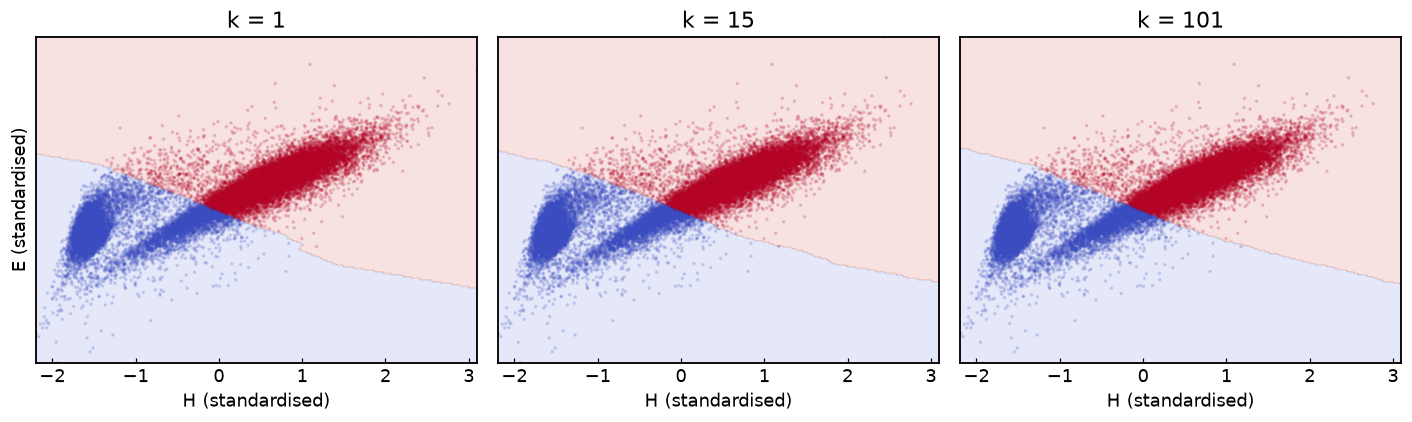

In [4]:
hh, ee = np.meshgrid(np.linspace(Xs[:, 0].min(), Xs[:, 0].max(), 200),
                     np.linspace(Xs[:, 1].min(), Xs[:, 1].max(), 200))
grid = np.c_[hh.ravel(), ee.ravel()]

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, k in zip(ax, [1, 15, 101]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
    zz = knn.predict(grid).reshape(hh.shape)
    a.contourf(hh, ee, zz, alpha=.15, cmap="coolwarm")
    a.scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, s=2, cmap="coolwarm", alpha=.15)
    a.set_title(f"k = {k}"); a.set_xlabel("H (standardised)"); a.set_yticks([])
ax[0].set_ylabel("E (standardised)"); fig.tight_layout()

*🖼 **Figure.** Left (k=1): the boundary wraps around individual points — it has memorised the training data (overfitting). Right (k=101): a smooth boundary that may miss fine structure (underfitting). The middle is usually the sweet spot.*

## 3 · Which k is best? Look at test accuracy

The boundary pictures are intuition; the number that matters is accuracy on the **held-out test set**.

> ✅ **Look for:** train and test accuracy vs k. On this large, cleanly-separable map every k scores ~0.99, so the test curve is nearly flat — the tell-tale sign of overfitting here is that **k = 1 scores a perfect 1.0 on *training*** but slightly less on the unseen test set.

best k by test accuracy: 5


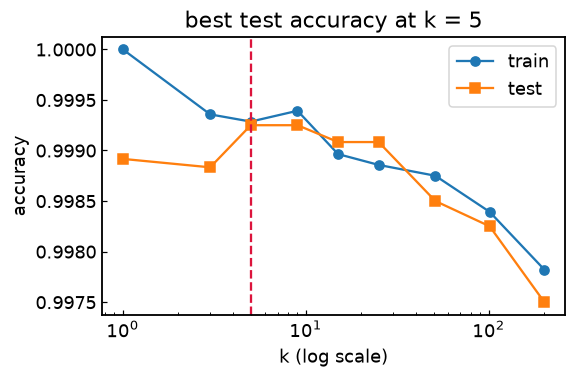

In [5]:
ks = [1, 3, 5, 9, 15, 25, 51, 101, 201]
acc_tr, acc_te = [], []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
    acc_tr.append(accuracy_score(ytr, knn.predict(Xtr)))    # accuracy on training data
    acc_te.append(accuracy_score(yte, knn.predict(Xte)))    # accuracy on unseen data

best_k = ks[int(np.argmax(acc_te))]
fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.plot(ks, acc_tr, "o-", label="train"); ax.plot(ks, acc_te, "s-", label="test")
ax.axvline(best_k, ls="--", c="crimson"); ax.set_xscale("log")
ax.set_xlabel("k (log scale)"); ax.set_ylabel("accuracy"); ax.legend()
ax.set_title(f"best test accuracy at k = {best_k}"); fig.tight_layout()
print("best k by test accuracy:", best_k)

*🖼 **Figure.** At k=1 training accuracy is a perfect 1.0 but test accuracy is lower — the tell-tale sign of **overfitting**. Test accuracy peaks at a moderate k, then slowly falls as the model over-smooths.*

### ✅ Self-check
A small guard on the results. Tweak the notebook and, if something drifts badly, this cell stops with an `AssertionError` instead of quietly returning nonsense.

In [6]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert max(acc_te) > 0.95, "k-NN should classify the two phases well on unseen data"
assert acc_tr[0] > 0.999, "at k=1 the model memorises training — a perfect train score is the overfitting signal"
print("self-check passed ✓ — k-NN classifies the phases well")

self-check passed ✓ — k-NN classifies the phases well


## ✅ Recap
- **k-NN** classifies by majority vote of the `k` closest labelled examples — no training step.
- **Small k overfits** (jagged, memorises), **large k underfits** (over-smooth); pick k by **test** accuracy.
- Always **standardise** first, or the feature with the biggest units hijacks the distance.

## 🔧 Try it yourself
A handful of variations worth trying (re-run each time):
1. Add `HE` as a third feature. Does the best k or the test accuracy change?
2. Skip the standardisation (fit k-NN on raw `X`). Does accuracy get worse? Why?
3. Set `weights="distance"` in `KNeighborsClassifier` so closer neighbours count more. Does it help at large k?

## 🩹 Common errors & fixes
- **Accuracy is 1.0 on training but poor on test** → that's overfitting at small k, not a bug.
- **k-NN feels slow at prediction** → it compares to every training point; reduce features or use approximate neighbours.
- **Boundary ignores one axis** → you probably didn't standardise; distance is then dominated by the larger-unit feature.

---
**Next:** **`03a_evaluating_models.ipynb`** — cross-validation, precision/recall and ROC: how to *trust* any of these accuracy numbers.